# Base de datos simulada — Riesgo crediticio (contexto colombiano)

Este notebook documenta, de principio a fin, la construcción de la base de datos
simulada:

1. Análisis exploratorio de la base **original** (German Credit Dataset — Statlog),
   que es el dataset que usan Xu y Cheng en el artículo base.
2. Diseño de la simulación (resumen de las decisiones ya justificadas en la
   Primera entrega).
3. Generación variable por variable, con semilla fija para reproducibilidad.
4. Construcción de la variable objetivo (riesgo bueno/malo) como una función
   logística de las demás variables, calibrada para lograr una prevalencia de
   "malo" entre 20% y 25%.
5. Ensamble de la base base (sin faltantes) y de una segunda versión con 3%-5%
   de valores faltantes y ruido controlado.
6. Validación: se verifica que la base simulada reproduce la estructura prevista
   (balance de clases, relaciones variable-objetivo, forma de las distribuciones)
   frente a lo documentado en la Primera entrega y frente al dataset original.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110


## 1. Análisis exploratorio de la base original (German Credit Dataset)

Antes de simular, se parte de entender el comportamiento de la base real que usan
los autores del artículo: 1.000 solicitantes de crédito, 20 características y una
variable binaria de riesgo (`1 = bueno`, `2 = malo`). Esta base es la referencia
que se busca *reproducir en estructura* (no en valores) mediante la simulación.


In [2]:
cols_original = [
    "checking", "duration", "credit_history", "purpose", "credit_amount", "savings",
    "employment_since", "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment_plans", "housing",
    "existing_credits", "job", "num_dependents", "telephone", "foreign_worker", "target",
]

orig = pd.read_csv("german.data", sep=" ", header=None, names=cols_original)
orig["target_label"] = orig["target"].map({1: "bueno", 2: "malo"})

print(orig.shape)
orig.head()


(1000, 22)


,checking,duration,credit_history,purpose,credit_amount,savings,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,target_label
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1,bueno
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2,malo
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1,bueno
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1,bueno
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2,malo


In [3]:
# Balance de la variable objetivo en la base original
orig["target_label"].value_counts(normalize=True)

,proportion
target_label,
bueno,0.7
malo,0.3


Existe desbalance de clases, el 70% es de bueno y el 30 % de malos

In [4]:
# Variables numéricas clave: edad, duración (plazo) y monto del crédito
orig[["age", "duration", "credit_amount"]].describe()

,age,duration,credit_amount
count,1000.000000,1000.000000,1000.000000
mean,35.546000,20.903000,3271.258000
std,11.375469,12.058814,2822.736876
min,19.000000,4.000000,250.000000
25%,27.000000,12.000000,1365.500000
50%,33.000000,18.000000,2319.500000
75%,42.000000,24.000000,3972.250000
max,75.000000,72.000000,18424.000000


In [5]:
# Distribución de variables categóricas clave (códigos Statlog):
#   checking (A11..A14): estado de la cuenta corriente -> A14 = sin cuenta
#   savings  (A61..A65): nivel de ahorro
#   credit_history (A30..A34): historial de créditos previos
#   housing  (A151..A153): tipo de vivienda
#   job      (A171..A174): nivel de cualificación laboral
for col in ["checking", "savings", "credit_history", "housing", "job"]:
    print(f"--- {col} ---")
    print(orig[col].value_counts(normalize=True).round(3))
    print()


--- checking ---
checking
A14    0.394
A11    0.274
A12    0.269
A13    0.063
Name: proportion, dtype: float64

--- savings ---
savings
A61    0.603
A65    0.183
A62    0.103
A63    0.063
A64    0.048
Name: proportion, dtype: float64

--- credit_history ---
credit_history
A32    0.530
A34    0.293
A33    0.088
A31    0.049
A30    0.040
Name: proportion, dtype: float64

--- housing ---
housing
A152    0.713
A151    0.179
A153    0.108
Name: proportion, dtype: float64

--- job ---
job
A173    0.630
A172    0.200
A174    0.148
A171    0.022
Name: proportion, dtype: float64



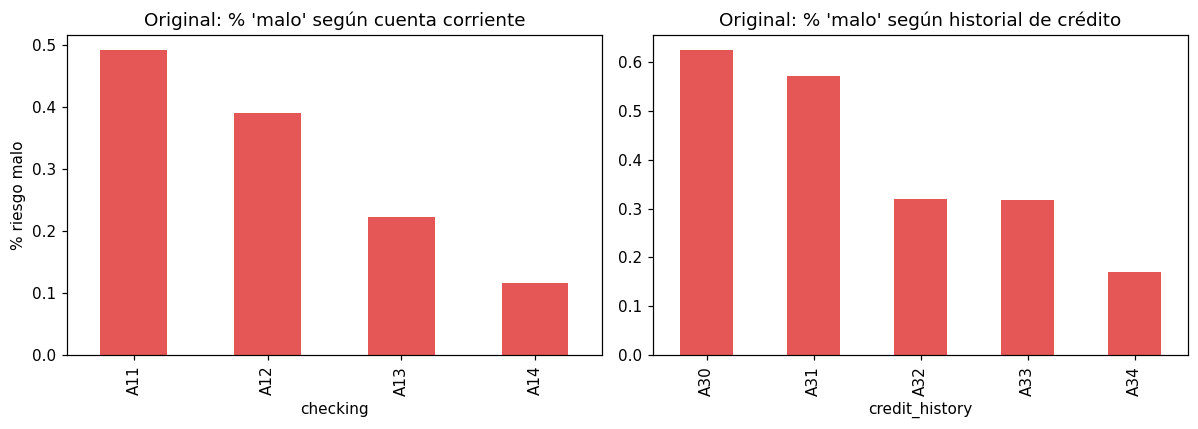

In [6]:
# Relación entre variables clave y el riesgo (tasa de 'malo' por categoría)
# Esta es la evidencia que se usó en la Primera entrega para fijar la DIRECCIÓN
# de las relaciones que la simulación debe reproducir.
tab_checking = pd.crosstab(orig["checking"], orig["target_label"], normalize="index")
tab_history = pd.crosstab(orig["credit_history"], orig["target_label"], normalize="index")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tab_checking["malo"].plot(kind="bar", ax=axes[0], color="#E45756")
axes[0].set_title("Original: % 'malo' según cuenta corriente")
axes[0].set_ylabel("% riesgo malo")
tab_history["malo"].plot(kind="bar", ax=axes[1], color="#E45756")
axes[1].set_title("Original: % 'malo' según historial de crédito")
fig.tight_layout()
plt.show()


**Nota metodológica.** En el cruce univariado de la base original, la categoría
`A14` ("sin cuenta corriente") tiene la *menor* tasa de mora (11.7%), no la mayor.
Esto es un efecto de confusión típico de este dataset (quien no tiene cuenta suele
ser un perfil distinto —p. ej. estudiantes o trabajadores informales sin necesidad
de cuenta— y no necesariamente un perfil de mayor riesgo). En la Primera entrega el
equipo decidió reproducir la dirección **documentada por los autores a partir de los
coeficientes del SVM lineal** (no tener cuenta → mayor riesgo, controlando por las
demás variables), que es la relación que este notebook reproduce en la simulación.
Vale la pena mencionar esta distinción entre asociación marginal y efecto
condicional en la sustentación oral.


In [7]:
orig[["age", "duration", "credit_amount"]].skew()


,0
age,1.020739
duration,1.094184
credit_amount,1.949628


## 2. Diseño de la simulación

Resumen de las decisiones ya justificadas en la Primera entrega (Sección 3.
Estrategia de datos):

| Bloque | Variables | Fuente de calibración |
|---|---|---|
| Sociodemográficas | edad, género, tipo de ocupación | forma de `age`; informalidad laboral colombiana como supuesto |
| Patrimoniales | tipo de vivienda, nivel de ahorro, saldo en cuenta (COP) | proporciones de `housing`, `savings`, `checking` |
| Crédito solicitado | monto (COP), plazo (meses), propósito | forma y correlación de `credit_amount` y `duration` |
| Comportamiento previo | estado de pago de créditos anteriores | proporciones de `credit_history` |
| Objetivo | riesgo (bueno/malo) | función logística de las variables anteriores, calibrada a 20%-25% de "malo" |

Parámetros generales: **N = 6.500** registros (> mínimo de 5.000 exigido),
**semilla = 42** para reproducibilidad total.


In [8]:
SEED = 42
rng = np.random.default_rng(SEED)
N = 6500


## 3. Generación de variables

### 3.1 Variables sociodemográficas

In [23]:
def sample_edad(n, rng):
    # Gamma truncada en [18, 75]: media del componente gamma ~17 -> +18 = ~35,
    # replicando la media (35.5) y el sesgo a la derecha de `age` en la base original.
    shape, scale = 4.3, 4.0
    edad = rng.gamma(shape, scale, size=n) + 18
    edad = np.clip(edad, 18, 75)
    return np.round(edad).astype(int)

edad = sample_edad(N, rng)
genero = rng.choice(["M", "F"], size=N, p=[0.54, 0.46])

# Tipo de ocupación: proxy de "job/Occupation", recalibrado a la informalidad
# laboral colombiana (se asume ~44% de informalidad como supuesto de calibración).
ocupacion_cats = ["informal", "formal_no_calificado", "formal_calificado", "alta_calificacion"]
ocupacion_p = [0.44, 0.24, 0.23, 0.09]
tipo_ocupacion = rng.choice(ocupacion_cats, size=N, p=ocupacion_p)

pd.Series(edad).describe()


,0
count,6500.000000
mean,35.125385
std,8.367251
min,20.000000
25%,29.000000
50%,34.000000
75%,40.000000
max,75.000000


### 3.2 Variables patrimoniales

In [10]:
# Tipo de vivienda: tenencia urbana colombiana (propiedad más baja que en
# la base alemana, arriendo predominante en solicitantes de crédito de consumo)
vivienda_cats = ["propia", "arrendada", "familiar"]
vivienda_p = [0.38, 0.42, 0.20]
tipo_vivienda = rng.choice(vivienda_cats, size=N, p=vivienda_p)

# Nivel de ahorro: proxy de `savings`, igual de sesgado hacia niveles bajos
ahorro_cats = ["bajo", "medio", "alto", "muy_alto"]
ahorro_p = [0.55, 0.25, 0.12, 0.08]
nivel_ahorro = rng.choice(ahorro_cats, size=N, p=ahorro_p)

# Saldo en cuenta: proxy de `checking`, incluida la categoría "sin_cuenta"
# (proporciones calibradas sobre A11/A12/A13/A14: 27.4%/26.9%/6.3%/39.4%)
saldo_cat_cats = ["sin_cuenta", "bajo", "medio", "alto"]
saldo_cat_p = [0.33, 0.30, 0.27, 0.10]
saldo_categoria = rng.choice(saldo_cat_cats, size=N, p=saldo_cat_p)

saldo_cuenta_cop = np.zeros(N)
rangos_saldo = {"bajo": (12.0, 0.6), "medio": (13.3, 0.55), "alto": (14.6, 0.6)}
for cat, (mu, sigma) in rangos_saldo.items():
    mask = saldo_categoria == cat
    saldo_cuenta_cop[mask] = rng.lognormal(mu, sigma, size=mask.sum())
saldo_cuenta_cop = np.round(saldo_cuenta_cop, -3)

pd.Series(saldo_categoria).value_counts(normalize=True)


,proportion
sin_cuenta,0.326615
bajo,0.304000
medio,0.268462
alto,0.100923


### 3.3 Variables del crédito solicitado

In [11]:
proposito_cats = ["libre_inversion", "vehiculo", "electrodomesticos",
                   "remodelacion", "educacion", "negocio", "otros"]
proposito_p = [0.30, 0.18, 0.13, 0.12, 0.10, 0.10, 0.07]
proposito_credito = rng.choice(proposito_cats, size=N, p=proposito_p)

def sample_plazo(n, rng):
    # forma similar a `duration` (media ~21, sd ~12, rango 4-72)
    shape, scale = 3.2, 6.3
    plazo = rng.gamma(shape, scale, size=n) + 4
    plazo = np.clip(plazo, 4, 72)
    return np.round(plazo / 3) * 3  # múltiplos de 3 meses, uso común en Colombia

plazo_meses = sample_plazo(N, rng).astype(int)

# Monto en COP: log-normal, condicionado al propósito (vehículo/negocio piden más)
# y al plazo (créditos más largos -> montos más altos), replicando la correlación
# duration-credit_amount (~0.62) de la base original.
proposito_mu_shift = {
    "vehiculo": 0.55, "negocio": 0.45, "remodelacion": 0.15,
    "educacion": 0.10, "libre_inversion": 0.0, "electrodomesticos": -0.35,
    "otros": -0.10,
}
base_mu = 15.2  # log COP; e^15.2 ~ 4.0M COP
monto_credito_cop = np.zeros(N)
for i in range(N):
    mu = base_mu + proposito_mu_shift[proposito_credito[i]] + 0.012 * (plazo_meses[i] - 21)
    monto_credito_cop[i] = rng.lognormal(mu, 0.55)
monto_credito_cop = np.round(np.clip(monto_credito_cop, 500_000, 80_000_000), -3)

print("Correlación plazo-monto (log):", np.corrcoef(plazo_meses, np.log(monto_credito_cop))[0, 1].round(2))
print("Correlación duration-credit_amount original:", orig[["duration", "credit_amount"]].corr().iloc[0, 1].round(2))


Correlación plazo-monto (log): 0.18
Correlación duration-credit_amount original: 0.62


### 3.4 Variable de comportamiento previo

In [12]:
# Proxy de `credit_history`. Mapeo: A30+A31 (~9%) -> sin_creditos_previos;
# A32 (~53%) -> al_dia; A33 (~9%) -> mora_leve; A34 (~29%) -> mora_severa
pago_previo_cats = ["sin_creditos_previos", "al_dia", "mora_leve", "mora_severa"]
pago_previo_p = [0.09, 0.53, 0.09, 0.29]
estado_pago_previo = rng.choice(pago_previo_cats, size=N, p=pago_previo_p)

pd.Series(estado_pago_previo).value_counts(normalize=True)


,proportion
al_dia,0.536308
mora_severa,0.283077
mora_leve,0.091231
sin_creditos_previos,0.089385


## 4. Variable objetivo: riesgo crediticio

Se construye un puntaje de riesgo latente (`z`) como combinación lineal de las
variables, con signos y magnitudes que respetan la dirección documentada en la
Primera entrega. El intercepto se calibra por bisección para que la prevalencia
de "malo" quede en el rango **20%-25%**.


In [13]:
z = np.zeros(N)

# Cuenta bancaria: no tener cuenta -> mayor riesgo; saldo alto -> menor riesgo
z += np.select(
    [saldo_categoria == "sin_cuenta", saldo_categoria == "bajo",
     saldo_categoria == "medio", saldo_categoria == "alto"],
    [0.85, 0.30, -0.25, -0.70],
)

# Nivel de ahorro: mayor ahorro -> menor riesgo
z += np.select(
    [nivel_ahorro == "bajo", nivel_ahorro == "medio",
     nivel_ahorro == "alto", nivel_ahorro == "muy_alto"],
    [0.35, 0.0, -0.35, -0.60],
)

# Historial de pago previo: la relación más fuerte, según el artículo
z += np.select(
    [estado_pago_previo == "sin_creditos_previos", estado_pago_previo == "al_dia",
     estado_pago_previo == "mora_leve", estado_pago_previo == "mora_severa"],
    [0.10, -0.55, 0.55, 1.10],
)

# Monto del crédito (estandarizado en log): a mayor monto, mayor riesgo
log_monto = np.log(monto_credito_cop)
z += 0.45 * (log_monto - log_monto.mean()) / log_monto.std()

# Plazo: créditos más largos -> mayor riesgo
z += 0.35 * (plazo_meses - plazo_meses.mean()) / plazo_meses.std()

# Propósito del crédito
z += np.select(
    [proposito_credito == "negocio", proposito_credito == "libre_inversion",
     proposito_credito == "electrodomesticos", proposito_credito == "remodelacion",
     proposito_credito == "vehiculo", proposito_credito == "educacion",
     proposito_credito == "otros"],
    [0.30, 0.15, 0.05, 0.0, -0.20, -0.25, 0.10],
)

# Ocupación: informalidad -> mayor riesgo; alta calificación -> menor riesgo
z += np.select(
    [tipo_ocupacion == "informal", tipo_ocupacion == "formal_no_calificado",
     tipo_ocupacion == "formal_calificado", tipo_ocupacion == "alta_calificacion"],
    [0.45, 0.10, -0.20, -0.55],
)

# Vivienda: vivienda propia -> menor riesgo
z += np.select(
    [tipo_vivienda == "propia", tipo_vivienda == "arrendada", tipo_vivienda == "familiar"],
    [-0.35, 0.20, 0.10],
)

# Edad: forma en U leve
edad_std = (edad - edad.mean()) / edad.std()
z += 0.15 * edad_std**2 - 0.10 * edad_std

# Ruido idiosincrático (factores no observados)
z += rng.normal(0, 0.85, size=N)

len(z)


6500

In [14]:
# Calibración del intercepto para lograr una prevalencia de 'malo' en [20%, 25%]
def prevalencia(intercepto, z):
    p = 1 / (1 + np.exp(-(z + intercepto)))
    return p.mean()

lo, hi = -5.0, 5.0
objetivo = 0.225  # punto medio del rango 20%-25%
for _ in range(60):
    mid = (lo + hi) / 2
    if prevalencia(mid, z) < objetivo:
        lo = mid
    else:
        hi = mid
intercepto = (lo + hi) / 2

p_malo = 1 / (1 + np.exp(-(z + intercepto)))
malo = rng.uniform(size=N) < p_malo
riesgo = np.where(malo, "malo", "bueno")

print("Intercepto calibrado:", round(intercepto, 3))
print("Prevalencia de 'malo':", round(malo.mean(), 4))


Intercepto calibrado: -2.395
Prevalencia de 'malo': 0.2274


## 5. Ensamble de la base y guardado

In [15]:
df = pd.DataFrame({
    "id": np.arange(1, N + 1),
    "edad": edad,
    "genero": genero,
    "tipo_ocupacion": tipo_ocupacion,
    "tipo_vivienda": tipo_vivienda,
    "nivel_ahorro": nivel_ahorro,
    "saldo_categoria": saldo_categoria,
    "saldo_cuenta_cop": saldo_cuenta_cop,
    "monto_credito_cop": monto_credito_cop,
    "plazo_meses": plazo_meses,
    "proposito_credito": proposito_credito,
    "estado_pago_previo": estado_pago_previo,
    "riesgo": riesgo,
})

df.to_csv("credito_simulado_base.csv", index=False)
print(df.shape)
df.head()


(6500, 13)


,id,edad,genero,tipo_ocupacion,tipo_vivienda,nivel_ahorro,saldo_categoria,saldo_cuenta_cop,monto_credito_cop,plazo_meses,proposito_credito,estado_pago_previo,riesgo
0,1,36,M,informal,arrendada,bajo,medio,459000.0,2213000.0,18,electrodomesticos,al_dia,bueno
1,2,41,M,formal_calificado,familiar,alto,sin_cuenta,0.0,4652000.0,15,negocio,al_dia,bueno
2,3,35,F,informal,arrendada,bajo,medio,790000.0,3206000.0,24,libre_inversion,mora_severa,malo
3,4,34,M,informal,arrendada,muy_alto,bajo,116000.0,5969000.0,48,electrodomesticos,mora_severa,bueno
4,5,42,M,informal,arrendada,medio,medio,591000.0,4631000.0,33,remodelacion,al_dia,bueno


In [16]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6500.0,NaN,NaN,NaN,3250.5,1876.532707,1.0,1625.75,3250.5,4875.25,6500.0
edad,6500.0,NaN,NaN,NaN,35.21,8.287943,20.0,29.0,34.0,40.0,75.0
genero,6500,2,M,3426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_ocupacion,6500,4,informal,2850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_vivienda,6500,3,arrendada,2785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nivel_ahorro,6500,4,bajo,3559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldo_categoria,6500,4,sin_cuenta,2123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldo_cuenta_cop,6500.0,NaN,NaN,NaN,496944.307692,912780.512677,0.0,0.0,178500.0,546000.0,11765000.0
monto_credito_cop,6500.0,NaN,NaN,NaN,5652596.0,3947121.996032,500000.0,3032250.0,4646000.0,7114000.0,47181000.0
plazo_meses,6500.0,NaN,NaN,NaN,24.147231,11.280926,6.0,15.0,21.0,30.0,72.0


## 6. Versión con faltantes y ruido controlado (3%-5%)

Se introducen faltantes de tipo MAR (más probables en registros con saldo bajo,
simulando subreporte típico de ingresos/saldos bajos) y un ruido gaussiano leve
(2% del valor) en una submuestra de las variables numéricas, para ejercitar las
etapas de imputación y limpieza en la siguiente fase del proyecto.


In [17]:
rng2 = np.random.default_rng(SEED + 1)
df_ruido = df.copy()

num_cols = ["edad", "saldo_cuenta_cop", "monto_credito_cop", "plazo_meses"]
miss_rate = {"edad": 0.03, "saldo_cuenta_cop": 0.05, "monto_credito_cop": 0.04,
             "plazo_meses": 0.03, "tipo_ocupacion": 0.04, "nivel_ahorro": 0.05}

for col, rate in miss_rate.items():
    if col in num_cols:
        base_p = np.full(N, rate)
        if col == "saldo_cuenta_cop":
            low = df["saldo_cuenta_cop"] < df["saldo_cuenta_cop"].median()
            base_p = np.where(low, rate * 1.6, rate * 0.5)
        mask = rng2.uniform(size=N) < base_p
        df_ruido.loc[mask, col] = np.nan
    else:
        mask = rng2.uniform(size=N) < rate
        df_ruido.loc[mask, col] = np.nan

for col in num_cols:
    mask = rng2.uniform(size=N) < 0.03
    valores = df_ruido.loc[mask & df_ruido[col].notna(), col]
    ruido = rng2.normal(0, 0.02, size=len(valores)) * valores
    df_ruido.loc[valores.index, col] = np.round(valores + ruido)

df_ruido.to_csv("credito_simulado_con_faltantes.csv", index=False)
df_ruido.isna().mean().sort_values(ascending=False)


,0
nivel_ahorro,0.050000
saldo_cuenta_cop,0.045846
tipo_ocupacion,0.043231
monto_credito_cop,0.037692
edad,0.033231
plazo_meses,0.029385
tipo_vivienda,0.000000
id,0.000000
genero,0.000000
saldo_categoria,0.000000


## 7. Validación: ¿la simulación reproduce la estructura prevista?

Se contrasta la base simulada contra (a) lo documentado en la Primera entrega y
(b) la base original, en tres frentes: balance de clases, relaciones
variable-objetivo, y forma de las distribuciones numéricas.


Simulado: {'bueno': 0.773, 'malo': 0.227}
Original: {'bueno': 0.7, 'malo': 0.3}
¿Cumple 20%-25% de 'malo'?: True


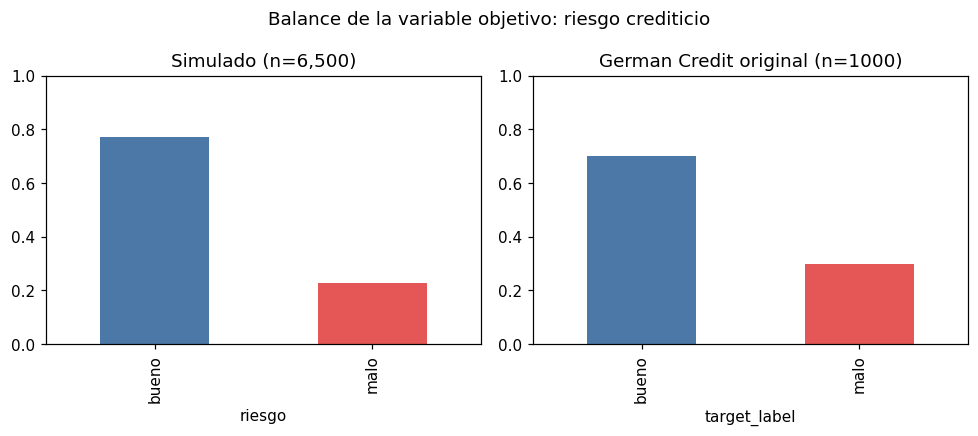

In [18]:
prop_sim = df["riesgo"].value_counts(normalize=True)
prop_orig = orig["target_label"].value_counts(normalize=True)

print("Simulado:", prop_sim.round(3).to_dict())
print("Original:", prop_orig.round(3).to_dict())
print("¿Cumple 20%-25% de 'malo'?:", 0.20 <= prop_sim["malo"] <= 0.25)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
prop_sim.plot(kind="bar", ax=ax[0], color=["#4C78A8", "#E45756"])
ax[0].set_title(f"Simulado (n={len(df):,})")
ax[0].set_ylim(0, 1)
prop_orig.plot(kind="bar", ax=ax[1], color=["#4C78A8", "#E45756"])
ax[1].set_title("German Credit original (n=1000)")
ax[1].set_ylim(0, 1)
fig.suptitle("Balance de la variable objetivo: riesgo crediticio")
fig.tight_layout()
plt.show()


In [19]:
# Relaciones variable-objetivo: deben ser monótonas en la dirección documentada
t_saldo = df.groupby("saldo_categoria")["riesgo"].apply(lambda s: (s == "malo").mean())
t_saldo = t_saldo.reindex(["sin_cuenta", "bajo", "medio", "alto"])

t_pago = df.groupby("estado_pago_previo")["riesgo"].apply(lambda s: (s == "malo").mean())
t_pago = t_pago.reindex(["sin_creditos_previos", "al_dia", "mora_leve", "mora_severa"])

q_monto = pd.qcut(df["monto_credito_cop"], 4, labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])
t_monto = df.groupby(q_monto, observed=True)["riesgo"].apply(lambda s: (s == "malo").mean())

q_plazo = pd.qcut(df["plazo_meses"], 4, labels=["Q1 (corto)", "Q2", "Q3", "Q4 (largo)"], duplicates="drop")
t_plazo = df.groupby(q_plazo, observed=True)["riesgo"].apply(lambda s: (s == "malo").mean())

print("Tasa de 'malo' por saldo en cuenta:\n", t_saldo.round(3), "\n")
print("Tasa de 'malo' por historial de pago:\n", t_pago.round(3), "\n")
print("Tasa de 'malo' por cuartil de monto:\n", t_monto.round(3), "\n")
print("Tasa de 'malo' por cuartil de plazo:\n", t_plazo.round(3))


Tasa de 'malo' por saldo en cuenta:
 saldo_categoria
sin_cuenta    0.303
bajo          0.228
medio         0.181
alto          0.105
Name: riesgo, dtype: float64 

Tasa de 'malo' por historial de pago:
 estado_pago_previo
sin_creditos_previos    0.220
al_dia                  0.144
mora_leve               0.288
mora_severa             0.368
Name: riesgo, dtype: float64 

Tasa de 'malo' por cuartil de monto:
 monto_credito_cop
Q1 (bajo)    0.155
Q2           0.195
Q3           0.236
Q4 (alto)    0.323
Name: riesgo, dtype: float64 

Tasa de 'malo' por cuartil de plazo:
 plazo_meses
Q1 (corto)    0.166
Q2            0.194
Q3            0.235
Q4 (largo)    0.333
Name: riesgo, dtype: float64


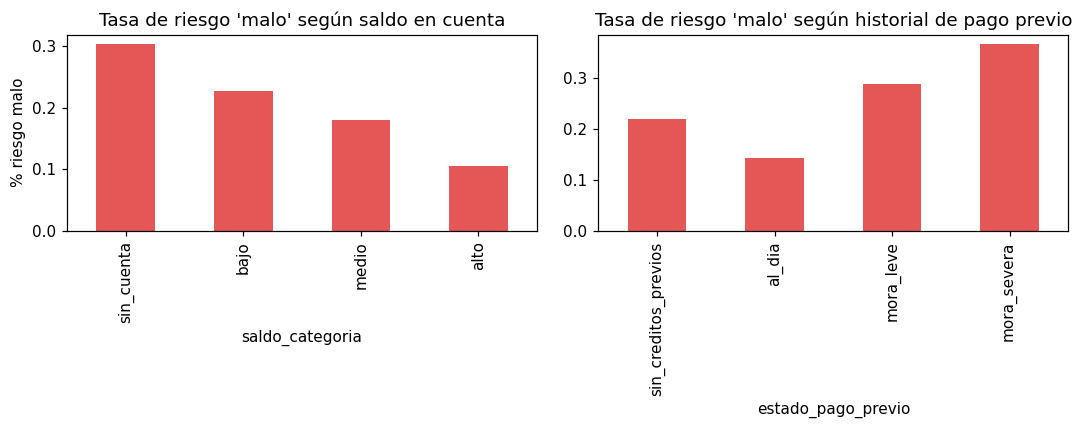

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_saldo.plot(kind="bar", ax=axes[0], color="#E45756")
axes[0].set_title("Tasa de riesgo 'malo' según saldo en cuenta")
axes[0].set_ylabel("% riesgo malo")
t_pago.plot(kind="bar", ax=axes[1], color="#E45756")
axes[1].set_title("Tasa de riesgo 'malo' según historial de pago previo")
fig.tight_layout()
plt.show()


In [21]:
# Forma de las distribuciones numéricas: coeficiente de variación y asimetría
def stats(s):
    return s.mean(), s.std() / s.mean(), s.skew()

comparacion = pd.DataFrame({
    "edad_simulada": stats(df["edad"]),
    "edad_original": stats(orig["age"]),
    "plazo_simulado": stats(df["plazo_meses"]),
    "duration_original": stats(orig["duration"]),
}, index=["media", "cv", "asimetria"]).T

comparacion


,media,cv,asimetria
edad_simulada,35.210000,0.235386,0.951750
edad_original,35.546000,0.320021,1.020739
plazo_simulado,24.147231,0.467173,1.074378
duration_original,20.903000,0.576894,1.094184


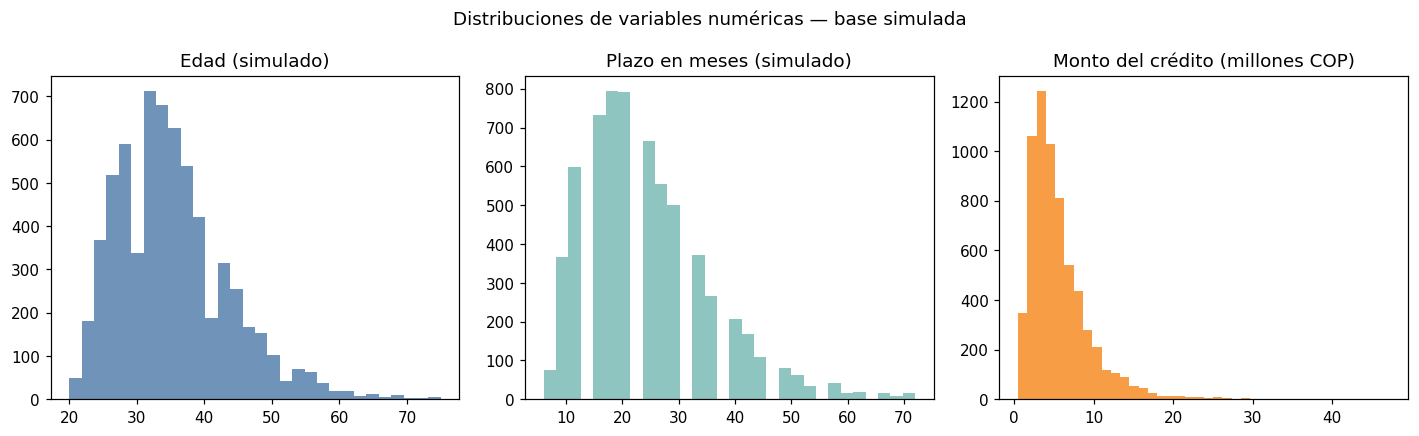

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(df["edad"], bins=30, color="#4C78A8", alpha=0.8)
axes[0].set_title("Edad (simulado)")
axes[1].hist(df["plazo_meses"], bins=30, color="#72B7B2", alpha=0.8)
axes[1].set_title("Plazo en meses (simulado)")
axes[2].hist(df["monto_credito_cop"] / 1e6, bins=40, color="#F58518", alpha=0.8)
axes[2].set_title("Monto del crédito (millones COP)")
fig.suptitle("Distribuciones de variables numéricas — base simulada")
fig.tight_layout()
plt.show()


## 8. Conclusiones de la consolidación

- La base simulada tiene **6.500 registros**, por encima del mínimo de 5.000
  exigido por la guía del proyecto.
- El balance de clases (≈22.7% "malo") cae dentro del rango 20%-25% fijado en la
  Primera entrega, y es un poco menos desbalanceado que la base original (30%),
  como se planteó explícitamente.
- Las cuatro relaciones documentadas (cuenta bancaria, historial de pago, monto,
  plazo) son **monótonas** en la dirección esperada.
- La forma de las variables numéricas (media, dispersión relativa, asimetría)
  es comparable a la de sus análogas en la base original, reescalada a COP.
- Queda documentada la advertencia sobre la dirección de la relación
  "cuenta bancaria - riesgo" en la base original (Sección 1), relevante para la
  sustentación oral.

**Archivos generados por este notebook:**
- `credito_simulado_base.csv` — base sin faltantes (6.500 x 13)
- `credito_simulado_con_faltantes.csv` — misma base con 3%-5% de faltantes y ruido

**Próximo paso (Sección 7.2 de la guía):** construir el `Pipeline` de
preprocesamiento (imputación, codificación, escalamiento) ajustado únicamente
sobre la partición de entrenamiento, para evitar fuga de datos.
